In [1]:
import pandas as pd 
import numpy as np
import joblib
import time
import sklearn.metrics
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, precision_recall_fscore_support, recall_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier
from lightgbm import LGBMClassifier

## Dataset Prepare

In [2]:
def calculate_macro_tpr_fpr(voting_cm):
    num_classes = voting_cm.shape[0]
    tpr_list = []
    fpr_list = []

    for i in range(num_classes):
        TP = voting_cm[i, i]
        FN = np.sum(voting_cm[i, :]) - TP
        FP = np.sum(voting_cm[:, i]) - TP
        TN = np.sum(voting_cm) - (TP + FN + FP)

        TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
        FPR = FP / (FP + TN) if (FP + TN) > 0 else 0

        tpr_list.append(TPR)
        fpr_list.append(FPR)

    macro_tpr = np.mean(tpr_list)
    macro_fpr = np.mean(fpr_list)

    return macro_tpr, macro_fpr

# Load models

In [3]:
test = pd.read_csv('./test_shap_65.csv')

X_test = test.drop(['Label'], axis=1)
y_test = test['Label']

In [17]:
# --- Load models ---
xgb_model = XGBClassifier()
xgb_model = joblib.load('./models/xgb_model_cfm.pkl')

rf_model = RandomForestClassifier()
rf_model = joblib.load('./models/rf_model_cfm.pkl')

et_model = ExtraTreesClassifier()
et_model = joblib.load('./models/et_model_cfm.pkl')

# --- Predict proba ---
xgb_preds = xgb_model.predict_proba(X_test)
rf_preds  = rf_model.predict_proba(X_test)
et_preds  = et_model.predict_proba(X_test)

# --- Predict labels ---
xgb_prediction = xgb_model.predict(X_test)
rf_prediction  = rf_model.predict(X_test)
et_prediction  = et_model.predict(X_test)

# --- Accuracy ---
xgb_acc = sklearn.metrics.accuracy_score(y_true=y_test, y_pred=xgb_prediction)
rf_acc  = sklearn.metrics.accuracy_score(y_true=y_test, y_pred=rf_prediction)
et_acc  = sklearn.metrics.accuracy_score(y_true=y_test, y_pred=et_prediction)

print("XGBoost Accuracy:", xgb_acc)
print("RandomForest Accuracy:", rf_acc)
print("ExtraTrees Accuracy:", et_acc)

# --- Macro-F1 ---
print("XGBoost Macro-F1:", f1_score(y_true=y_test, y_pred=xgb_prediction, average="macro"))
print("RandomForest Macro-F1:", f1_score(y_true=y_test, y_pred=rf_prediction, average="macro"))
print("ExtraTrees Macro-F1:", f1_score(y_true=y_test, y_pred=et_prediction, average="macro"))

XGBoost Accuracy: 0.8446745562130178
RandomForest Accuracy: 0.854043392504931
ExtraTrees Accuracy: 0.8589743589743589
XGBoost Macro-F1: 0.8378206966821753
RandomForest Macro-F1: 0.8482143723161543
ExtraTrees Macro-F1: 0.8551270484309854


# Train MLP Model

In [7]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler

# Load CFM augmented data
train_cfm = pd.read_csv('./dataset/CFM_augmented_9600.csv')

X_train_cfm = train_cfm.drop(['Label'], axis=1)
y_train_cfm = train_cfm['Label'].astype(int)

# Scale data
scaler_mlp = MinMaxScaler()
X_train_cfm_scaled = scaler_mlp.fit_transform(X_train_cfm)
X_test_scaled = scaler_mlp.transform(X_test)

# Train MLP
print("Training MLP model on CFM augmented data...")
mlp_model = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    batch_size=64,
    learning_rate='adaptive',
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42,
    verbose=True
)

mlp_model.fit(X_train_cfm_scaled, y_train_cfm)

# Save model
joblib.dump(mlp_model, './models/mlp_model_cfm.pkl')
joblib.dump(scaler_mlp, './models/mlp_scaler_cfm.pkl')
print("MLP model saved to ./models/mlp_model_cfm.pkl")

# Predict
mlp_preds = mlp_model.predict_proba(X_test_scaled)
mlp_prediction = mlp_model.predict(X_test_scaled)

# Accuracy
mlp_acc = sklearn.metrics.accuracy_score(y_true=y_test, y_pred=mlp_prediction)
mlp_f1 = f1_score(y_true=y_test, y_pred=mlp_prediction, average="macro")

print(f"\nMLP Accuracy: {mlp_acc}")
print(f"MLP Macro-F1: {mlp_f1}")

Training MLP model on CFM augmented data...
Iteration 1, loss = 1.50184414
Validation score: 0.484375
Iteration 2, loss = 0.88553243
Validation score: 0.554167
Iteration 3, loss = 0.84892078
Validation score: 0.562500
Iteration 4, loss = 0.83574406
Validation score: 0.586458
Iteration 5, loss = 0.82107010
Validation score: 0.613542
Iteration 6, loss = 0.80345780
Validation score: 0.616667
Iteration 7, loss = 0.79500308
Validation score: 0.622917
Iteration 8, loss = 0.78966368
Validation score: 0.623958
Iteration 9, loss = 0.77245430
Validation score: 0.610417
Iteration 10, loss = 0.76124775
Validation score: 0.661458
Iteration 11, loss = 0.75456265
Validation score: 0.635417
Iteration 12, loss = 0.74201399
Validation score: 0.608333
Iteration 13, loss = 0.73443623
Validation score: 0.647917
Iteration 14, loss = 0.72857764
Validation score: 0.629167
Iteration 15, loss = 0.71855267
Validation score: 0.671875
Iteration 16, loss = 0.71969376
Validation score: 0.643750
Iteration 17, loss = 


MLP Confusion Matrix:
 [[169   0   0   0   0   0   0   0   0   0   0   0]
 [  0 141  28   0   0   0   0   0   0   0   0   0]
 [  0  41 106   0   0   0   0  21   0   1   0   0]
 [  0   0   0  41   4  37  87   0   0   0   0   0]
 [  0   0   0  33  15  30  91   0   0   0   0   0]
 [  0   0   0  14   1 150   4   0   0   0   0   0]
 [  0   0   0   9   5  19 136   0   0   0   0   0]
 [  0   1   0   0   0   0   0 102  60   5   1   0]
 [  0   0   0   0   0   0   0  25 144   0   0   0]
 [  0   0   2   0   0   0   0  15   0 116  36   0]
 [  0   0   0   0   0   0   0   0   0 105  64   0]
 [  3   0   0   0   0   0   0   0   0   0   0 166]]


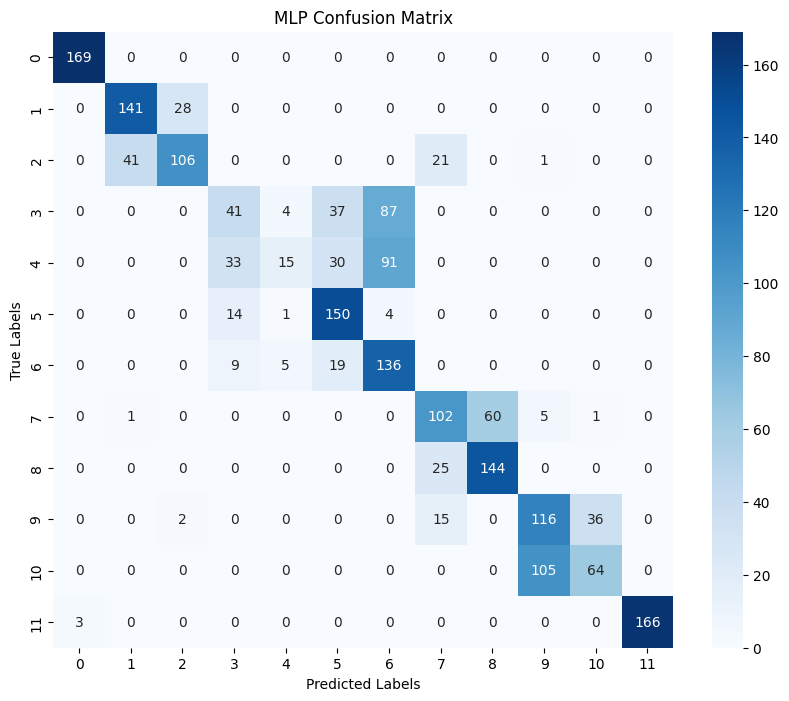

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# Confusion Matrix
mlp_cm = confusion_matrix(y_true=y_test, y_pred=mlp_prediction)
print("\nMLP Confusion Matrix:\n", mlp_cm)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(mlp_cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('MLP Confusion Matrix')
plt.show()

# Train TabNet Model

Training TabNet model on CFM augmented data...


/data2/cmdir/home/giangnl1/dis/IDS/DABEL25/.conda/lib/python3.11/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 1.71123 | test_accuracy: 0.07594 |  0:00:03s
epoch 1  | loss: 0.97045 | test_accuracy: 0.15089 |  0:00:14s
epoch 2  | loss: 0.88732 | test_accuracy: 0.214   |  0:00:16s
epoch 3  | loss: 0.83905 | test_accuracy: 0.13116 |  0:00:19s
epoch 4  | loss: 0.79474 | test_accuracy: 0.09813 |  0:00:22s
epoch 5  | loss: 0.79628 | test_accuracy: 0.29043 |  0:00:24s
epoch 6  | loss: 0.79316 | test_accuracy: 0.3787  |  0:00:27s
epoch 7  | loss: 0.76319 | test_accuracy: 0.50542 |  0:00:30s
epoch 8  | loss: 0.73812 | test_accuracy: 0.48274 |  0:00:32s
epoch 9  | loss: 0.73046 | test_accuracy: 0.54586 |  0:00:35s
epoch 10 | loss: 0.71948 | test_accuracy: 0.57594 |  0:00:38s
epoch 11 | loss: 0.7247  | test_accuracy: 0.63462 |  0:00:41s
epoch 12 | loss: 0.74942 | test_accuracy: 0.59911 |  0:00:43s
epoch 13 | loss: 0.7297  | test_accuracy: 0.63609 |  0:00:47s
epoch 14 | loss: 0.70499 | test_accuracy: 0.64398 |  0:00:50s
epoch 15 | loss: 0.70026 | test_accuracy: 0.62574 |  0:00:53s
epoch 16

/data2/cmdir/home/giangnl1/dis/IDS/DABEL25/.conda/lib/python3.11/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Successfully saved model at ./models/tabnet_model_cfm.zip
TabNet model saved to ./models/tabnet_model_cfm

TabNet Accuracy: 0.6977317554240631
TabNet Macro-F1: 0.6827404792699773

TabNet Confusion Matrix:
 [[169   0   0   0   0   0   0   0   0   0   0   0]
 [  0 138  31   0   0   0   0   0   0   0   0   0]
 [  0  27 128   0   0   0   0  14   0   0   0   0]
 [  0   0   0  37  21  31  80   0   0   0   0   0]
 [  0   0   0  21  47  22  79   0   0   0   0   0]
 [  0   0   0  15  11 143   0   0   0   0   0   0]
 [  0   0   0   4  12  18 135   0   0   0   0   0]
 [  0   1  15   0   0   0   0  89  63   0   1   0]
 [  0   0   0   0   0   0   0  17 152   0   0   0]
 [  0   0   7   0   0   0   0  11   0  94  57   0]
 [  0   0   0   0   0   0   0   0   0  53 116   0]
 [  1   0   1   0   0   0   0   0   0   0   0 167]]


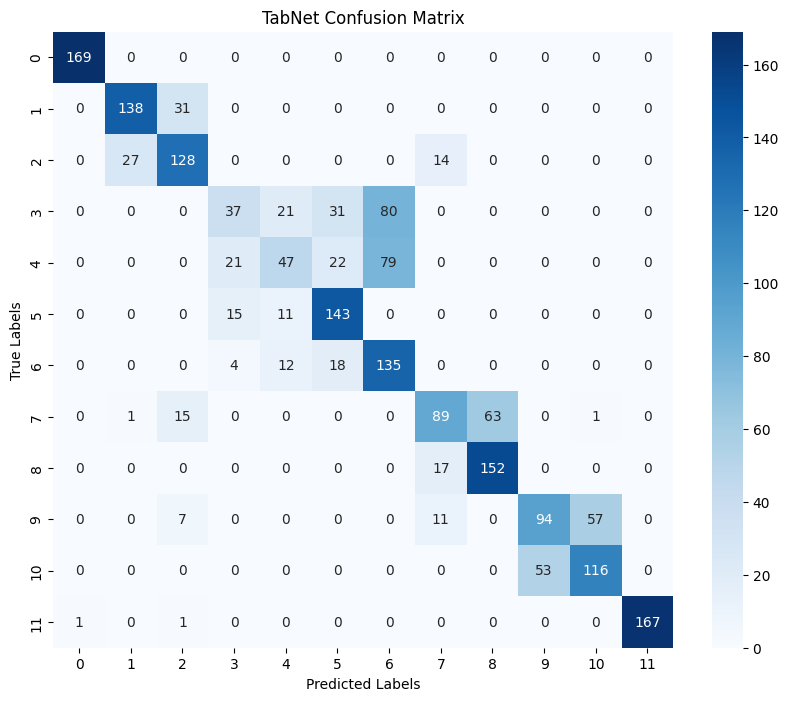

In [15]:
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

# Train TabNet
print("Training TabNet model on CFM augmented data...")
tabnet_model = TabNetClassifier(
    n_d=64,
    n_a=64,
    n_steps=5,
    gamma=1.5,
    n_independent=2,
    n_shared=2,
    lambda_sparse=1e-4,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    scheduler_params=dict(step_size=10, gamma=0.9),
    mask_type='entmax',
    seed=42,
    verbose=1
)

tabnet_model.fit(
    X_train=X_train_cfm_scaled,
    y_train=y_train_cfm.values,
    eval_set=[(X_test_scaled, y_test.values)],
    eval_name=['test'],
    eval_metric=['accuracy'],
    max_epochs=100,
    patience=20,
    batch_size=256,
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False
)

# Save model
tabnet_model.save_model('./models/tabnet_model_cfm')
print("TabNet model saved to ./models/tabnet_model_cfm")

# Predict
tabnet_preds = tabnet_model.predict_proba(X_test_scaled)
tabnet_prediction = tabnet_model.predict(X_test_scaled)

# Accuracy
tabnet_acc = sklearn.metrics.accuracy_score(y_true=y_test, y_pred=tabnet_prediction)
tabnet_f1 = f1_score(y_true=y_test, y_pred=tabnet_prediction, average="macro")

print(f"\nTabNet Accuracy: {tabnet_acc}")
print(f"TabNet Macro-F1: {tabnet_f1}")

# Confusion Matrix
tabnet_cm = confusion_matrix(y_true=y_test, y_pred=tabnet_prediction)
print("\nTabNet Confusion Matrix:\n", tabnet_cm)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(tabnet_cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('TabNet Confusion Matrix')
plt.show()

# Train FT-Transformer Model

Training FT-Transformer model on CFM augmented data...
Training on device: cpu
Epoch 10/100, Train Loss: 1.1296, Val Acc: 0.5291
Epoch 20/100, Train Loss: 1.0349, Val Acc: 0.5390
Epoch 30/100, Train Loss: 0.9744, Val Acc: 0.5725
Epoch 40/100, Train Loss: 0.9398, Val Acc: 0.5621
Epoch 50/100, Train Loss: 0.9148, Val Acc: 0.5740
Early stopping at epoch 50
FT-Transformer model saved to ./models/ftt_model_cfm.pth

FT-Transformer Accuracy: 0.5739644970414202
FT-Transformer Macro-F1: 0.5380376327842282

FT-Transformer Confusion Matrix:
 [[159   1   3   1   1   0   0   1   0   2   1   0]
 [  6 129  34   0   0   0   0   0   0   0   0   0]
 [  3  54  89   0   0   0   1  22   0   0   0   0]
 [  0   0   0   5   7  85  66   3   1   2   0   0]
 [  0   0   1   3   7  87  68   1   1   1   0   0]
 [  0   0   0   3   0  89  67   3   7   0   0   0]
 [  0   0   0   2   7  43 117   0   0   0   0   0]
 [  0   0   3   0   6   2   0  94  55   4   5   0]
 [  0   0   0   0   5   1   0  13 149   1   0   0]
 [  

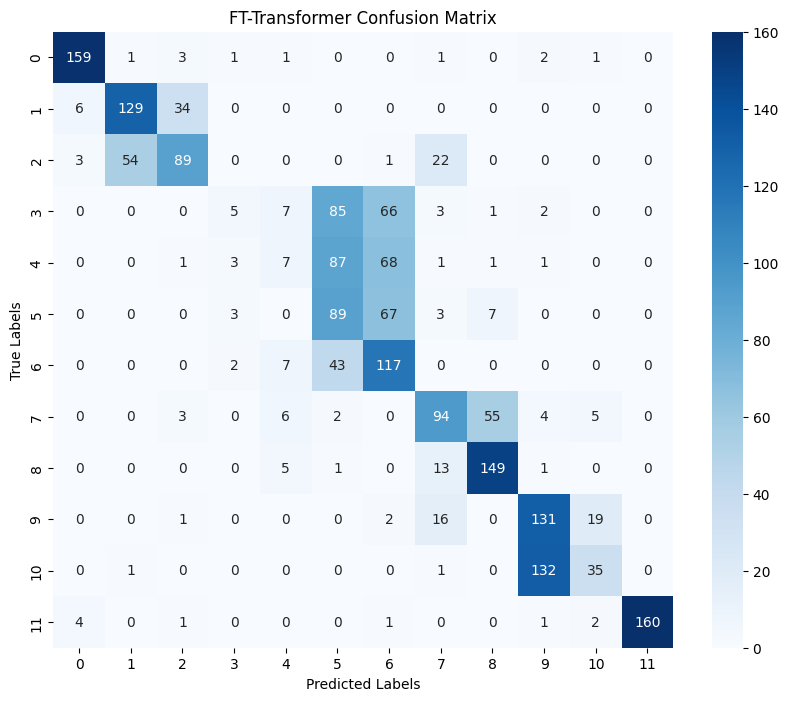

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# FT-Transformer implementation
class FTTransformer(nn.Module):
    def __init__(self, n_features, n_classes, d_model=64, n_heads=4, n_layers=3, dropout=0.1):
        super().__init__()
        self.feature_embedding = nn.Linear(1, d_model)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=n_heads, 
            dim_feedforward=d_model*4,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.fc = nn.Linear(d_model, n_classes)
        self.n_features = n_features
        
    def forward(self, x):
        # x: (batch, n_features)
        batch_size = x.size(0)
        x = x.unsqueeze(-1)  # (batch, n_features, 1)
        x = self.feature_embedding(x)  # (batch, n_features, d_model)
        
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)  # (batch, n_features+1, d_model)
        
        x = self.transformer(x)
        cls_output = x[:, 0]  # (batch, d_model)
        return self.fc(cls_output)

# Training function
def train_ftt_model(X_train, y_train, X_val, y_val, n_classes, epochs=100, batch_size=128, lr=1e-3, patience=15):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Training on device: {device}")
    
    # Prepare data
    X_train_t = torch.FloatTensor(X_train).to(device)
    y_train_t = torch.LongTensor(y_train).to(device)
    X_val_t = torch.FloatTensor(X_val).to(device)
    y_val_t = torch.LongTensor(y_val).to(device)
    
    train_dataset = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    # Model
    n_features = X_train.shape[1]
    model = FTTransformer(n_features, n_classes, d_model=64, n_heads=4, n_layers=3).to(device)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()
    
    best_val_acc = 0
    best_model_state = None
    patience_counter = 0
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        scheduler.step()
        
        # Validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_t)
            val_preds = val_outputs.argmax(dim=1)
            val_acc = (val_preds == y_val_t).float().mean().item()
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss/len(train_loader):.4f}, Val Acc: {val_acc:.4f}")
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
    
    model.load_state_dict(best_model_state)
    return model, device

# Train FT-Transformer
print("Training FT-Transformer model on CFM augmented data...")
n_classes = len(np.unique(y_train_cfm))

ftt_model, ftt_device = train_ftt_model(
    X_train_cfm_scaled, 
    y_train_cfm.values, 
    X_test_scaled, 
    y_test.values,
    n_classes,
    epochs=100,
    batch_size=128,
    lr=1e-3,
    patience=15
)

# Save model
torch.save(ftt_model.state_dict(), './models/ftt_model_cfm.pth')
print("FT-Transformer model saved to ./models/ftt_model_cfm.pth")

# Predict
ftt_model.eval()
with torch.no_grad():
    X_test_t = torch.FloatTensor(X_test_scaled).to(ftt_device)
    ftt_outputs = ftt_model(X_test_t)
    ftt_preds = F.softmax(ftt_outputs, dim=1).cpu().numpy()
    ftt_prediction = ftt_outputs.argmax(dim=1).cpu().numpy()

# Accuracy
ftt_acc = sklearn.metrics.accuracy_score(y_true=y_test, y_pred=ftt_prediction)
ftt_f1 = f1_score(y_true=y_test, y_pred=ftt_prediction, average="macro")

print(f"\nFT-Transformer Accuracy: {ftt_acc}")
print(f"FT-Transformer Macro-F1: {ftt_f1}")

# Confusion Matrix
ftt_cm = confusion_matrix(y_true=y_test, y_pred=ftt_prediction)
print("\nFT-Transformer Confusion Matrix:\n", ftt_cm)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(ftt_cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('FT-Transformer Confusion Matrix')
plt.show()

# Weighted Voting Ensemble

In [21]:
# ====== cấu hình ======
metric = "f1"      # "f1" hoặc "recall"
step = 0.05
N = int(round(1/step))

# ====== danh sách proba của 6 mô hình: xgb, rf, et, mlp, tabnet, ftt ======
preds_list = [xgb_preds, rf_preds, et_preds, mlp_preds, tabnet_preds, ftt_preds]

best_score = -1.0
best_weights = None

# ====== search weights cho 6 mô hình ======
print("Searching for best weights (this may take a while)...")
for i in range(N + 1):
    for j in range(N + 1 - i):
        for k in range(N + 1 - i - j):
            for l in range(N + 1 - i - j - k):
                for m in range(N + 1 - i - j - k - l):
                    n = N - i - j - k - l - m

                    w1, w2, w3, w4, w5, w6 = i/N, j/N, k/N, l/N, m/N, n/N

                    proba = (w1*preds_list[0] + w2*preds_list[1] + w3*preds_list[2] + 
                             w4*preds_list[3] + w5*preds_list[4] + w6*preds_list[5])

                    pred = proba.argmax(axis=1)

                    if metric == "f1":
                        score = f1_score(y_test, pred, average='macro', zero_division=0)
                    else:
                        score = recall_score(y_test, pred, average='macro', zero_division=0)

                    if score > best_score:
                        best_score = score
                        best_weights = (w1, w2, w3, w4, w5, w6)

print("Best weights (xgb, rf, et, mlp, tabnet, ftt):", best_weights, "sum =", sum(best_weights))
print(f"Best {metric} (macro):", best_score)

# ====== AUC macro OVR tại trọng số tốt nhất ======
w1, w2, w3, w4, w5, w6 = best_weights
proba_best = (w1*preds_list[0] + w2*preds_list[1] + w3*preds_list[2] + 
              w4*preds_list[3] + w5*preds_list[4] + w6*preds_list[5])

try:
    from sklearn.metrics import roc_auc_score
    auc_macro_ovr = roc_auc_score(y_test, proba_best, multi_class='ovr', average='macro')
    print("AUC (macro, OVR):", auc_macro_ovr)
except ValueError as e:
    print("AUC không tính được:", e)

Searching for best weights (this may take a while)...
Best weights (xgb, rf, et, mlp, tabnet, ftt): (0.1, 0.15, 0.25, 0.15, 0.15, 0.2) sum = 1.0
Best f1 (macro): 0.861124449562373
AUC (macro, OVR): 0.9896768002138963


In [23]:
# Sử dụng best_weights từ grid search ở trên
w1, w2, w3, w4, w5, w6 = best_weights

avgs = (
    w1 * xgb_preds
    + w2 * rf_preds
    + w3 * et_preds
    + w4 * mlp_preds
    + w5 * tabnet_preds
    + w6 * ftt_preds
)

voting_prediction = avgs.argmax(axis=1)
voting_acc = sklearn.metrics.accuracy_score(y_true=y_test, y_pred=voting_prediction)
voting_precision = sklearn.metrics.precision_score(y_true=y_test, y_pred=voting_prediction, average='macro')
voting_f1 = sklearn.metrics.f1_score(y_true=y_test, y_pred=voting_prediction, average='macro')
voting_recall = sklearn.metrics.recall_score(y_true=y_test, y_pred=voting_prediction, average='macro')
voting_cm = sklearn.metrics.confusion_matrix(y_true=y_test, y_pred=voting_prediction)


# AUC-ROC calculation
# Convert y_test to binary indicator matrix if it isn't already
if y_test.ndim == 1 or y_test.shape[1] == 1:
    from sklearn.preprocessing import label_binarize
    y_test_binary = label_binarize(y_test, classes=range(avgs.shape[1]))
else:
    y_test_binary = y_test

# Compute the probabilities for each class
voting_probabilities = avgs / avgs.sum(axis=1, keepdims=True)  # Normalize probabilities

# Compute AUC-ROC for each label
auc_roc = sklearn.metrics.roc_auc_score(y_test_binary, voting_probabilities, average='macro', multi_class='ovr')

print("Voting report (XGBoost + RandomForest + ExtraTrees + MLP + TabNet + FT-Transformer):")
print(f"Weights: XGB={w1:.2f}, RF={w2:.2f}, ET={w3:.2f}, MLP={w4:.2f}, TabNet={w5:.2f}, FTT={w6:.2f}")
print("Voting Accuracy:", voting_acc)
print("Voting Precision:", voting_precision)
print("Voting F1:", voting_f1)
print("Voting Recall:", voting_recall)
print("Voting AUC-ROC:", auc_roc)
print("Voting CM:\n", voting_cm)
voting_tpr, voting_fpr = calculate_macro_tpr_fpr(voting_cm)
print(f'Voting Macro-average TPR: {voting_tpr}')
print(f'Voting Macro-average FPR: {voting_fpr}')

Voting report (XGBoost + RandomForest + ExtraTrees + MLP + TabNet + FT-Transformer):
Weights: XGB=0.10, RF=0.15, ET=0.25, MLP=0.15, TabNet=0.15, FTT=0.20
Voting Accuracy: 0.866370808678501
Voting Precision: 0.8639942214536078
Voting F1: 0.861124449562373
Voting Recall: 0.8663708086785009
Voting AUC-ROC: 0.9896768002138963
Voting CM:
 [[169   0   0   0   0   0   0   0   0   0   0   0]
 [  0 169   0   0   0   0   0   0   0   0   0   0]
 [  0   2 167   0   0   0   0   0   0   0   0   0]
 [  0   0   0 169   0   0   0   0   0   0   0   0]
 [  0   0   0   0 169   0   0   0   0   0   0   0]
 [  0   0   0   0   0 169   0   0   0   0   0   0]
 [  0   0   0   0   0   0 169   0   0   0   0   0]
 [  0   1  23   0   0   0   0  73  54   6  12   0]
 [  0   0   0   0   0   0   0  26 143   0   0   0]
 [  0   0   8   0   0   0   0   8   0 109  44   0]
 [  0   0   0   0   0   0   0   0   0  87  82   0]
 [  0   0   0   0   0   0   0   0   0   0   0 169]]
Voting Macro-average TPR: 0.8663708086785009
Voting

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(voting_cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()